In [1]:
import pandas as pd
import numpy as np
import ast
import re
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import log_loss, roc_auc_score, f1_score, brier_score_loss
import matplotlib.pyplot as plt

In [2]:
students = pd.read_csv("../Dataset/student.csv")
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   student_id                           17340 non-null  object 
 1   quiz_id                              17340 non-null  int64  
 2   session_id                           17340 non-null  object 
 3   question_id                          17340 non-null  int64  
 4   question_in_quiz                     17340 non-null  int64  
 5   difficulty                           17340 non-null  object 
 6   topic                                17340 non-null  object 
 7   response_time                        17340 non-null  float64
 8   accuracy_so_far                      17340 non-null  float64
 9   number_of_questions_answered_so_far  17340 non-null  int64  
 10  accuracy_easy_so_far                 17340 non-null  float64
 11  accuracy_medium_so_far      

In [3]:
questions = pd.read_csv("../Dataset/questions.csv")
questions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   question_id        150 non-null    int64  
 1   question_text      150 non-null    object 
 2   correct_answer     150 non-null    object 
 3   difficulty         150 non-null    object 
 4   num_words          150 non-null    int64  
 5   qstn_complexity    150 non-null    float64
 6   options_cleaned    150 non-null    object 
 7   num_options        150 non-null    int64  
 8   avg_option_length  150 non-null    float64
 9   embedding          150 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 11.8+ KB


In [4]:
# Merge students with questions on question_id
df = pd.merge(students, questions, on='question_id', how='inner')
df = df.drop(columns=['student_id', 'question_id', 'quiz_id', 'question_text', 'difficulty_x', 'options_cleaned', 'correct_answer', 'topic', 'response_time'])

df = df.rename(columns={'difficulty_y': 'difficulty'})
difficulty_mapping = {'easy': 0, 'medium': 1, 'hard': 2}
df['difficulty'] = df['difficulty'].map(difficulty_mapping)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 18 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   session_id                           17340 non-null  object 
 1   question_in_quiz                     17340 non-null  int64  
 2   accuracy_so_far                      17340 non-null  float64
 3   number_of_questions_answered_so_far  17340 non-null  int64  
 4   accuracy_easy_so_far                 17340 non-null  float64
 5   accuracy_medium_so_far               17340 non-null  float64
 6   accuracy_hard_so_far                 17340 non-null  float64
 7   average_response_time_so_far         17340 non-null  float64
 8   last_1_correctness                   17340 non-null  int64  
 9   last_2_correctness                   17340 non-null  int64  
 10  last_3_correctness                   17340 non-null  int64  
 11  correct                     

In [5]:
# If embedding is a space-separated numpy string representation
def parse_embedding(emb_str):
    if isinstance(emb_str, str):
        # Remove brackets and replace newlines/multiple spaces with single spaces
        clean_str = re.sub(r'[\[\]\n]', '', emb_str)
        # Parse into a numpy array of floats
        return np.fromstring(clean_str, sep=' ')
    return emb_str

df['embedding'] = df['embedding'].apply(parse_embedding)

# expand embedding into columns
emb_matrix = np.vstack(df['embedding'].values)

emb_cols = [f'emb_{i}' for i in range(emb_matrix.shape[1])]
emb_df = pd.DataFrame(emb_matrix, columns=emb_cols, index=df.index)

df = pd.concat([df, emb_df], axis=1)
df = df.drop(columns=['embedding'])

df.head()

,session_id,question_in_quiz,accuracy_so_far,number_of_questions_answered_so_far,accuracy_easy_so_far,accuracy_medium_so_far,accuracy_hard_so_far,average_response_time_so_far,last_1_correctness,last_2_correctness,...,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
0,0Hpj01paAdfZ_quiz_1,1,0.000000,0,0.000000,0.0,0.0,0.00,0,0,...,0.006189,0.099546,0.036238,-0.046583,-0.009744,-0.024358,0.105183,0.024318,-0.033074,0.042406
1,0Hpj01paAdfZ_quiz_1,2,0.000000,1,0.000000,0.0,0.0,24498.00,0,0,...,-0.007157,-0.006056,0.017018,-0.005366,-0.107050,-0.016052,0.003156,-0.052500,-0.040340,-0.001573
2,0Hpj01paAdfZ_quiz_1,3,0.500000,2,1.000000,0.0,0.0,16362.50,1,0,...,-0.016080,-0.009504,0.006815,0.000296,-0.070221,-0.005564,0.019933,-0.053693,-0.052701,-0.044281
3,0Hpj01paAdfZ_quiz_1,4,0.333333,3,0.500000,0.0,0.0,16416.00,0,1,...,0.059893,-0.056153,-0.024371,-0.026942,-0.020434,-0.002594,-0.023414,-0.061554,-0.066854,-0.063834
4,0Hpj01paAdfZ_quiz_1,5,0.500000,4,0.666667,0.0,0.0,15200.25,1,0,...,-0.060383,-0.025223,0.011502,-0.032220,-0.031510,0.032851,-0.007645,-0.022037,0.018972,-0.037396


In [6]:
#Group split (by session_id)
gss = GroupShuffleSplit(test_size=0.3, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['session_id']))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

In [7]:
#Separate features / target
X_train_full = train_df.drop(columns=['correct', 'session_id'])
y_train_full = train_df['correct']

X_test = test_df.drop(columns=['correct', 'session_id'])
y_test = test_df['correct']

# Initialize labeled / unlabeled pools
X_L, X_U, y_L, y_U = train_test_split(
    X_train_full, y_train_full,
    test_size=0.9,  # 10% labeled start
    random_state=42,
    stratify=y_train_full
)

In [8]:
def get_model():
    return XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )


def entropy(p):
    return -(p*np.log(p + 1e-10) + (1-p)*np.log(1-p + 1e-10))

In [ ]:
model = get_model()

best_loss = float("inf")
patience = 5
no_improve = 0
step_size = 0.05

history = []

total_size = len(X_train_full)

while True:

    # 1. Train
    model.fit(X_L, y_L)

    # 2. Predict on test
    probs_test = model.predict_proba(X_test)[:, 1]
    preds_test = (probs_test >= 0.5).astype(int)

    # 3. Metrics
    loss = log_loss(y_test, probs_test)
    auc = roc_auc_score(y_test, probs_test)
    f1 = f1_score(y_test, preds_test)
    brier = brier_score_loss(y_test, probs_test)

    # 4. Progress tracking
    labeled_ratio = len(X_L) / total_size

    history.append({
        "labeled_size": len(X_L),
        "labeled_ratio": labeled_ratio,
        "logloss": loss,
        "auc": auc,
        "f1": f1,
        "brier": brier
    })

    print(
        f"Labeled: {len(X_L)} ({labeled_ratio:.2%}) | "
        f"LogLoss: {loss:.4f} | AUC: {auc:.4f}"
    )

    # 5. Stopping criterion (LogLoss plateau)
    if best_loss - loss > 0.01:
        best_loss = loss
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience or len(X_U) == 0:
        break

    # 6. Uncertainty sampling (entropy)
    probs_unlabeled = model.predict_proba(X_U)[:, 1]
    ent = entropy(probs_unlabeled)

    k = max(1, int(step_size * len(X_U)))
    idx = np.argsort(ent)[-k:]

    # 7. Select samples
    X_selected = X_U.iloc[idx]
    y_selected = y_U.iloc[idx]

    # 8. Update pools
    X_L = pd.concat([X_L, X_selected])
    y_L = pd.concat([y_L, y_selected])

    X_U = X_U.drop(X_U.index[idx])
    y_U = y_U.drop(y_U.index[idx])

Labeled: 1212 (10.00%) | LogLoss: 0.4225 | AUC: 0.8289
Labeled: 1757 (14.50%) | LogLoss: 0.4073 | AUC: 0.8348
Labeled: 2275 (18.77%) | LogLoss: 0.3983 | AUC: 0.8400
Labeled: 2767 (22.83%) | LogLoss: 0.3964 | AUC: 0.8380
Labeled: 3234 (26.68%) | LogLoss: 0.3886 | AUC: 0.8451
Labeled: 3678 (30.35%) | LogLoss: 0.3840 | AUC: 0.8495
Labeled: 4100 (33.83%) | LogLoss: 0.3762 | AUC: 0.8551
Labeled: 4501 (37.14%) | LogLoss: 0.3735 | AUC: 0.8594
Labeled: 4881 (40.27%) | LogLoss: 0.3689 | AUC: 0.8637
Labeled: 5242 (43.25%) | LogLoss: 0.3668 | AUC: 0.8663
Labeled: 5585 (46.08%) | LogLoss: 0.3649 | AUC: 0.8689


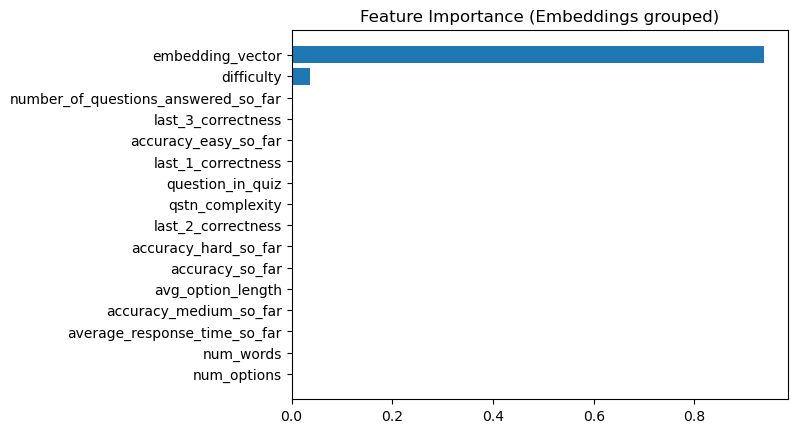

                                feature  importance
0                      embedding_vector    0.938049
10                           difficulty    0.036943
2   number_of_questions_answered_so_far    0.002444
9                    last_3_correctness    0.002379
3                  accuracy_easy_so_far    0.002210
7                    last_1_correctness    0.002205
0                      question_in_quiz    0.002204
12                      qstn_complexity    0.002110
8                    last_2_correctness    0.001953
5                  accuracy_hard_so_far    0.001926
1                       accuracy_so_far    0.001891
14                    avg_option_length    0.001852
4                accuracy_medium_so_far    0.001746
6          average_response_time_so_far    0.001529
11                            num_words    0.000560
13                          num_options    0.000000


In [10]:
importances = model.feature_importances_
feature_names = X_train_full.columns

fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# group embeddings
emb_df = fi_df[fi_df["feature"].str.startswith("emb_")]
other_df = fi_df[~fi_df["feature"].str.startswith("emb_")]

emb_grouped = pd.DataFrame({
    "feature": ["embedding_vector"],
    "importance": [emb_df["importance"].sum()]
})

final_fi = pd.concat([other_df, emb_grouped]).sort_values("importance", ascending=False)

# plot
top = final_fi.head(20)

plt.figure()
plt.barh(top["feature"][::-1], top["importance"][::-1])
plt.title("Feature Importance (Embeddings grouped)")
plt.show()

print(final_fi)

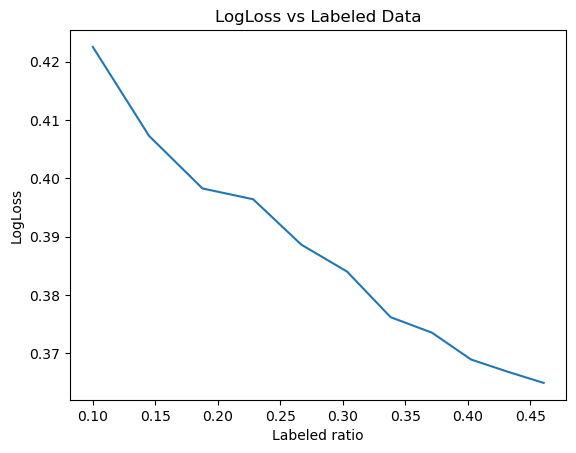

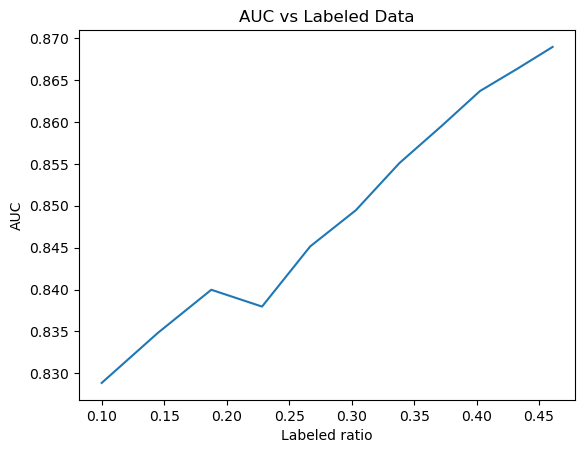

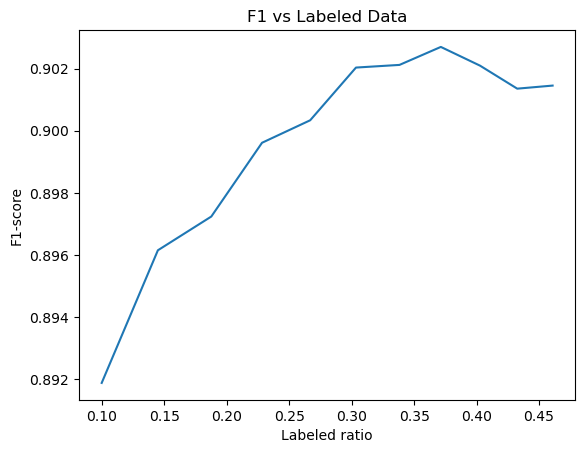

In [11]:
history_df = pd.DataFrame(history)

# LogLoss
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["logloss"])
plt.xlabel("Labeled ratio")
plt.ylabel("LogLoss")
plt.title("LogLoss vs Labeled Data")
plt.show()

# AUC
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["auc"])
plt.xlabel("Labeled ratio")
plt.ylabel("AUC")
plt.title("AUC vs Labeled Data")
plt.show()

# F1
plt.figure()
plt.plot(history_df["labeled_ratio"], history_df["f1"])
plt.xlabel("Labeled ratio")
plt.ylabel("F1-score")
plt.title("F1 vs Labeled Data")
plt.show()

In [ ]:
probs_test = model.predict_proba(X_test)[:, 1]

brier = brier_score_loss(y_test, probs_test)
auc = roc_auc_score(y_test, probs_test)
loss = log_loss(y_test, probs_test)

print(f"Brier: {brier:.4f}")
print(f"ROC AUC: {auc:.4f}")
print(f"LogLoss: {loss:.4f}")

Brier: 0.1123
ROC AUC: 0.8689
LogLoss: 0.3649
